# Milestone 2

## 1. Import Libraries and load data

Google Colab -> Files (the folder on the left) -> **Upload to session storage** *song_data.csv*

[Kaggle Dataset](https://www.kaggle.com/datasets/yasserh/song-popularity-dataset/data)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

RANDOM_SEED = 66
np.random.seed(RANDOM_SEED)

df = pd.read_csv('song_data.csv')
print(f"Original dataset shape: {df.shape}")

Original dataset shape: (18835, 15)


## 2. Improving Data Quality (Duplicates, Errors, and Outliers)

We will:
- Remove duplicates by keeping first occurences
- Remove zero-popularity songs
- Handle extreme outliers in song duration (unusually long or short songs that might confuse the model)

In [5]:
df = df.drop_duplicates(keep='first')

df = df[df['song_popularity'] > 0].copy()

Q1 = df['song_duration_ms'].quantile(0.25)
Q3 = df['song_duration_ms'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['song_duration_ms'] >= lower_bound) & (df['song_duration_ms'] <= upper_bound)].copy()

print(f"Shape after cleaning duplicates, errors, and outliers: {df.shape}")

Shape after cleaning duplicates, errors, and outliers: (14061, 15)


## 3. Feature Engineering

**What we are doing:** Creating 3 new features and 1 adjusted feature.
* **Intensity:** `energy` * `loudness`. Captures the power of a track.
* **Party Vibe:** Average of `danceability` and `energy`. Represents how club-ready a track is.
* **Duration in Minutes:** Converts milliseconds to minutes for a more human-readable feature.
* **Adjusted Tempo:** Halves the tempo if it exceeds 150 BPM to fix the "double tempo" tracking error identified in M1.

In [6]:
df['intensity'] = df['energy'] * df['loudness']

df['party_vibe'] = (df['danceability'] + df['energy']) / 2

df['duration_min'] = df['song_duration_ms'] / 60000

df['adj_tempo'] = df['tempo'].apply(lambda x: x / 2 if x > 150 else x)

## 4. Analysis of Newly Created Features
**What we are doing:** Analyzing how our new features correlate with our target variable (`song_popularity`).

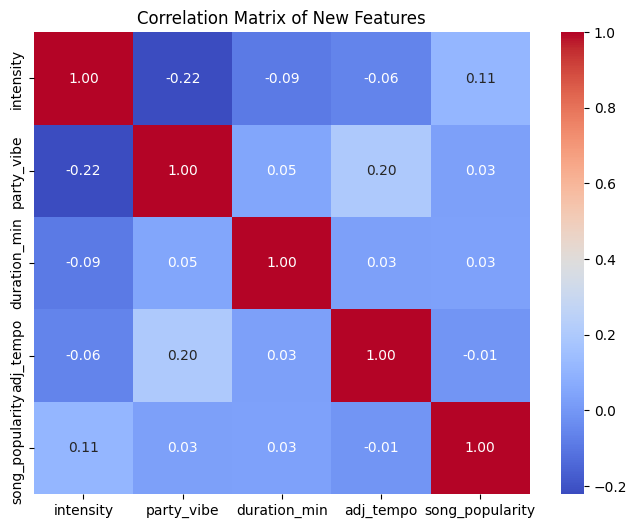

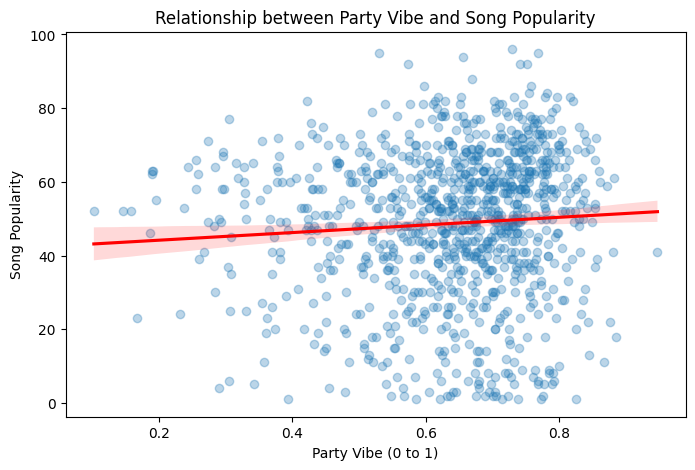

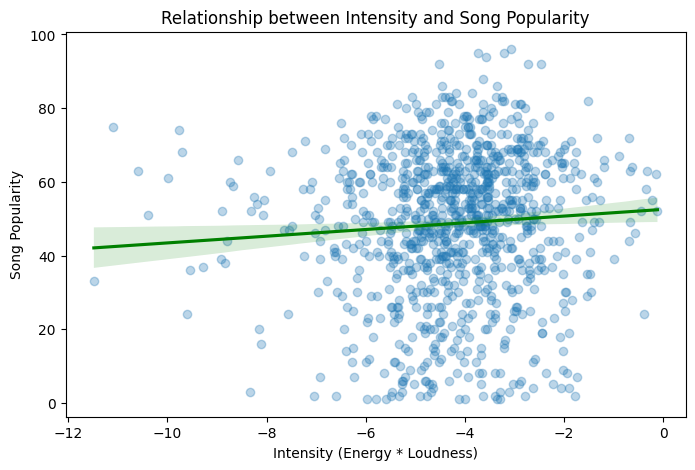

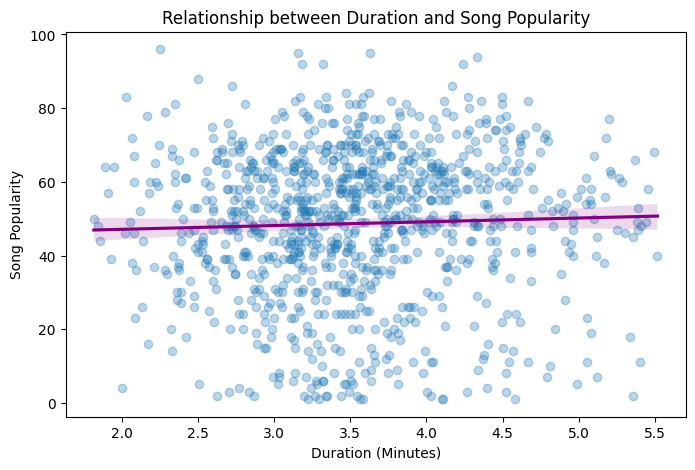

In [7]:
new_features = ['intensity', 'party_vibe', 'duration_min', 'adj_tempo', 'song_popularity']

plt.figure(figsize=(8, 6))
sns.heatmap(df[new_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of New Features")
plt.show()

print("\n\n\n")
plt.figure(figsize=(8, 5))
sns.regplot(data=df.sample(1000, random_state=RANDOM_SEED), x='party_vibe', y='song_popularity',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Relationship between Party Vibe and Song Popularity")
plt.xlabel("Party Vibe (0 to 1)")
plt.ylabel("Song Popularity")
plt.show()

print("\n\n\n")
plt.figure(figsize=(8, 5))
sns.regplot(data=df.sample(1000, random_state=RANDOM_SEED), x='intensity', y='song_popularity',
            scatter_kws={'alpha':0.3}, line_kws={'color':'green'})
plt.title("Relationship between Intensity and Song Popularity")
plt.xlabel("Intensity (Energy * Loudness)")
plt.ylabel("Song Popularity")
plt.show()

print("\n\n\n")
plt.figure(figsize=(8, 5))
sns.regplot(data=df.sample(1000, random_state=RANDOM_SEED), x='duration_min', y='song_popularity',
            scatter_kws={'alpha':0.3}, line_kws={'color':'purple'})
plt.title("Relationship between Duration and Song Popularity")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Song Popularity")
plt.show()

## 5. Preparation for Sklearn & Train-Test Split
- **What we are doing:** Dropping unhelpful text columns, One-Hot Encoding categorical variables, and splitting our data into Training (80%) and Testing (20%) sets.
- **Why:** *Crucially, we split the data BEFORE scaling.* If we scale the entire dataset at once, information from the test set leaks into the training set, ruining the integrity of our evaluation.

In [14]:
df_model = df.drop(['song_name', 'tempo', 'song_duration_ms'], axis=1)

df_model = pd.get_dummies(df_model, columns=['key', 'time_signature'], drop_first=True)

X = df_model.drop('song_popularity', axis=1)
y = df_model['song_popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

print("\n\n\nVerifying target distributions such that they are similar:")
print("Target Distribution - Training Set:")
print(y_train.describe()[['mean', 'std', 'min', 'max']])
print("\nTarget Distribution - Testing Set:")
print(y_test.describe()[['mean', 'std', 'min', 'max']])

Training set size: 11248 samples
Testing set size: 2813 samples



Verifying target distributions such that they are similar:
Target Distribution - Training Set:
mean     49.766536
std      19.535499
min       1.000000
max     100.000000
Name: song_popularity, dtype: float64

Target Distribution - Testing Set:
mean    49.552435
std     19.831487
min      1.000000
max     98.000000
Name: song_popularity, dtype: float64


## 6. Pre-Processing: Scaling
**What we are doing:** Applying `StandardScaler` to continuous variables.
**Why:** Features like `duration_min` and `loudness` operate on completely different numerical scales than features like `acousticness` (0 to 1). Scaling ensures that large numbers don't artificially dominate the model's learning process.

In [9]:
scaler = StandardScaler()

cont_features = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                 'liveness', 'loudness', 'audio_valence', 'intensity',
                 'party_vibe', 'duration_min', 'adj_tempo', 'speechiness']

X_train[cont_features] = scaler.fit_transform(X_train[cont_features])
X_test[cont_features] = scaler.transform(X_test[cont_features])

## 7. Feature Selection
**What we are doing:** Training a baseline Random Forest Regressor to extract Feature Importances.
**Why:** This allows us to mathematically verify which features are driving the predictions and which features are useless noise, helping us refine our model for Milestone 3.

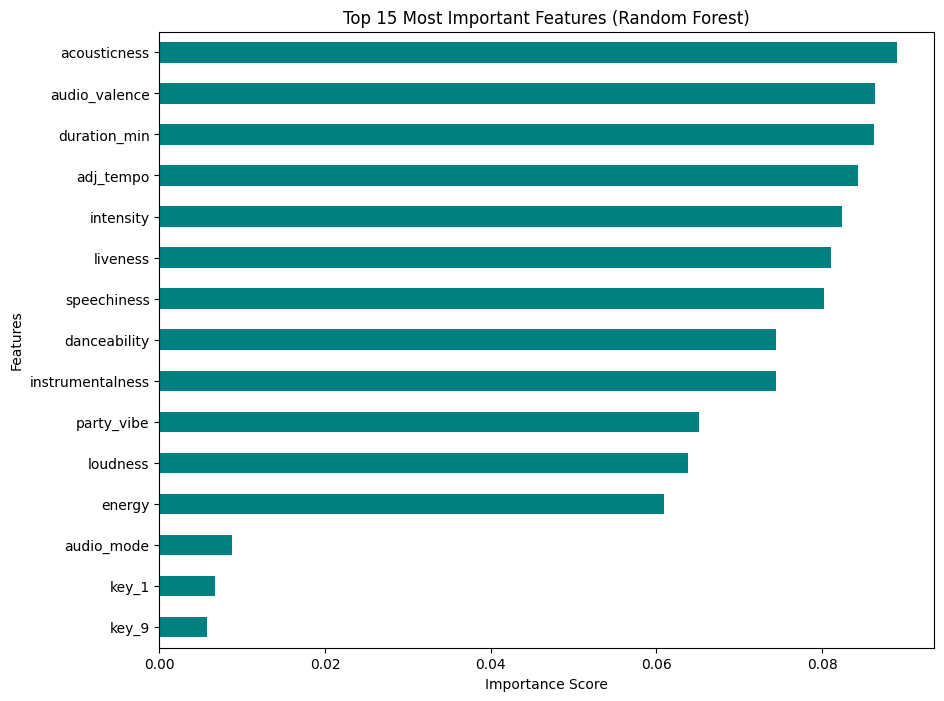

In [10]:
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 8))
importances.nlargest(15).sort_values().plot(kind='barh', color='teal')
plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [11]:
X_train.to_csv('X_train_prepared.csv', index=False)
X_test.to_csv('X_test_prepared.csv', index=False)
y_train.to_csv('y_train_prepared.csv', index=False)
y_test.to_csv('y_test_prepared.csv', index=False)

print("Data exported")

Data exported
